# Asset allocations using manually defined weights

In [31]:
import yfinance as yf
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [32]:
# Let's set all the starting prices to 1. 
def norm_prices(raw_df):
    norm_df = raw_df.copy()
    for i in raw_df.columns:
          norm_df[i] = raw_df[i]/raw_df[i][0]
    return norm_df

In [60]:
# Stocks, weights and initial investment
tickers = ["AMD","SNOW","TMO"]
weights = [0.3,0.3,0.4]
time_period = "1y"
initial_investment = 10000

In [61]:
def portfolio_performance(tickers, weights, time_period, initial_investment):
    dfs = {t: yf.Ticker(t).history(period=time_period) for t in tickers}
    close_df = pd.concat({t: df["Close"] for t, df in dfs.items()}, axis=1)
    portfolio_df = close_df.copy()
    norm_df = norm_prices(portfolio_df)

    for i, stock in enumerate(norm_df.columns):
        portfolio_df[stock] = weights[i] * norm_df[stock]  * initial_investment
    portfolio_df.round(1)
    portfolio_df['Portfolio Value'] = portfolio_df.sum(axis = 1, numeric_only = True)
    net_return = 100*(portfolio_df["Portfolio Value"][-1]-portfolio_df["Portfolio Value"][0])/portfolio_df["Portfolio Value"][0]
    net_return = net_return.round(1)
    print("Net return of the portfolio over the time period {} = {}%".format(time_period, net_return))

    # Creating the layout of the figure
    fig = make_subplots(rows=2, cols=1, specs=[[{"type": "xy"}],[{"type": "xy"}]],row_heights=[0.5,0.5],
        subplot_titles=["Individual Closing Prices [$]", "Portfolio Value [$]"])

    # Plot time series on the top panel
    fig.add_trace(
        go.Scatter(x=portfolio_df.index,y=portfolio_df["Portfolio Value"], mode="lines", name="Portfolio"),
    row=2,col=1)

    for tckr in tickers:
        fig.add_trace(
            go.Scatter(x=close_df.index,y=close_df[tckr], 
                       mode="lines", name=tckr),
        row=1,col=1)

    # Layout tweaks
    fig.update_layout(template="plotly_white",height=800, showlegend=True)

    fig.show()

Net return of the portfolio over the time period 1y = 38.3%


/var/folders/zd/5tclx9553z5cr_l9rz0l5svc0000gr/T/ipykernel_32339/3614890241.py:5: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/zd/5tclx9553z5cr_l9rz0l5svc0000gr/T/ipykernel_32339/1738318230.py:11: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



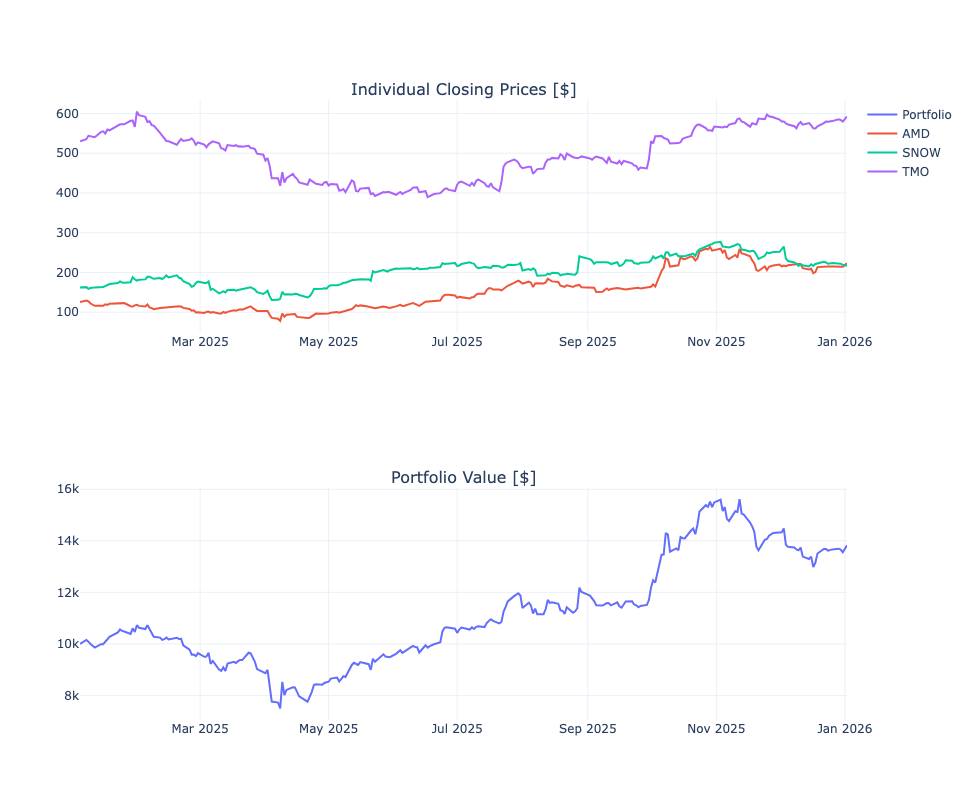

In [62]:
portfolio_performance(tickers, weights, time_period, initial_investment)